Cell 1: Check dataset path and dataset contents

In [1]:
import os
print(os.listdir('/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT'))

['SeaLake', 'Highway', 'River', 'Pasture', 'Industrial', 'Residential', 'PermanentCrop', 'validation.csv', 'AnnualCrop', 'train.csv', 'test.csv', 'label_map.json', 'Forest', 'HerbaceousVegetation']


Cell 2: Display one example image from the dataset

Text(0.5, 1.0, 'Example image from EuroSAT - Forest')

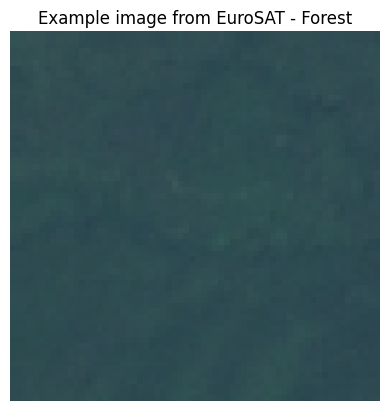

In [2]:
import os
import matplotlib.pyplot as plt
from PIL import Image

path = "/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT/Forest"

img_name = os.listdir(path)[0]
img = Image.open(os.path.join(path, img_name))

plt.imshow(img)
plt.axis("off")
plt.title("Example image from EuroSAT - Forest")

**Cell 3: Main imports for the ML pipeline**

In [3]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim
from collections import Counter

from copy import deepcopy


from PIL import Image
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms, models

print("Libraries loaded successfully")

Libraries loaded successfully


Cell 4: Define dataset path

In [4]:
data_path = "/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT"
print("Dataset path:", data_path)

Dataset path: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT


Cell 4.2: set random seeds

In [5]:
import random
import numpy as np
import torch

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed fixed:", seed)

Seed fixed: 42


Cell 5: Define image preprocessing pipeline for ResNet50; separate transforms for training and validation/test


In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Train and validation/test transforms are ready")

Train and validation/test transforms are ready


Cell 6: Load the full EuroSAT dataset using ImageFolder without transform for stratified split

In [7]:
dataset = datasets.ImageFolder(
    root=data_path
)

print("Dataset size:", len(dataset))
print("Classes:", dataset.classes)

Dataset size: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


Cell 7: Stratified split into train / validation / test with separate transforms

In [8]:
# Get labels from ImageFolder dataset
labels = dataset.targets
indices = list(range(len(dataset)))

# First split: Train+Val and Test (10% test)
train_val_idx, test_idx = train_test_split(
    indices,
    test_size=0.1,
    stratify=labels,
    random_state=42
)

# Get labels for remaining data
train_val_labels = [labels[i] for i in train_val_idx]

# Second split: Train and Validation
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.1111,   # makes validation ≈10% of total
    stratify=train_val_labels,
    random_state=42
)

# Create separate dataset copies with different transforms
train_dataset_full = deepcopy(dataset)
val_dataset_full = deepcopy(dataset)
test_dataset_full = deepcopy(dataset)

train_dataset_full.transform = train_transform
val_dataset_full.transform = val_test_transform
test_dataset_full.transform = val_test_transform

# Create subsets
train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(val_dataset_full, val_idx)
test_dataset = Subset(test_dataset_full, test_idx)

# Print sizes
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

print(dataset.classes)
print(dataset.class_to_idx)

print("Train distribution:", Counter([labels[i] for i in train_idx]))
print("Validation distribution:", Counter([labels[i] for i in val_idx]))
print("Test distribution:", Counter([labels[i] for i in test_idx]))

Train size: 21600
Validation size: 2700
Test size: 2700
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}
Train distribution: Counter({7: 2400, 2: 2400, 1: 2400, 9: 2400, 0: 2400, 8: 2000, 3: 2000, 6: 2000, 4: 2000, 5: 1600})
Validation distribution: Counter({1: 300, 2: 300, 0: 300, 9: 300, 7: 300, 4: 250, 8: 250, 3: 250, 6: 250, 5: 200})
Test distribution: Counter({1: 300, 9: 300, 0: 300, 7: 300, 2: 300, 4: 250, 6: 250, 3: 250, 8: 250, 5: 200})


Cell 8: Create DataLoaders for training, validation, and testing


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train, validation, and test DataLoaders are ready")

Train, validation, and test DataLoaders are ready


Cell 9: Inspect one batch from the training DataLoader


In [10]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("Example labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Example labels: tensor([4, 9, 4, 1, 4, 2, 0, 6, 2, 0])


**Cell 10: Load pretrained ResNet-50 model**

In [11]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

print("Pretrained ResNet-50 loaded successfully")
print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 193MB/s]


Pretrained ResNet-50 loaded successfully
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d

Cell 11: Replace the final classification layer for EuroSAT (10 classes)


In [12]:
model.fc = nn.Linear(model.fc.in_features, 10)

print("Final classification layer replaced successfully")
print(model.fc)

Final classification layer replaced successfully
Linear(in_features=2048, out_features=10, bias=True)


Cell 12: Move model to device (CPU or GPU)


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Model is running on:", device)

Model is running on: cuda


Cell 13: Define loss function and optimizer


In [14]:
# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Optimizer to update model weights
optimizer = optim.Adam(model.parameters(), lr=0.0001)
#The learning rate (lr) controls how big the weight updates are during training.
#During training the model does: prediction → calculate error → update weights. 
#The learning rate determines how big that update step is.

print("Loss function and optimizer initialized")

Loss function and optimizer initialized


Cell 14: Training function for one epoch


In [15]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()  # set model to training mode

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        # move data to GPU or CPU
        images, labels = images.to(device), labels.to(device)

        # clear previous gradients
        optimizer.zero_grad()

        # forward pass
        outputs = model(images)

        # compute loss
        loss = criterion(outputs, labels)

        # backward pass
        loss.backward()

        # update model weights
        optimizer.step()

        # accumulate loss
        running_loss += loss.item() * images.size(0)

        # calculate accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

Cell 15: Define validation function


In [16]:
def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()  # set model to evaluation mode

    running_loss = 0.0
    correct = 0
    total = 0

    # disable gradient computation (faster and uses less memory)
    with torch.no_grad():

        for images, labels in val_loader:
            # move data to device
            images, labels = images.to(device), labels.to(device)

            # forward pass
            outputs = model(images)

            # compute loss
            loss = criterion(outputs, labels)

            # accumulate loss
            running_loss += loss.item() * images.size(0)

            # calculate accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

Cell 16: Multi-epoch training loop


In [17]:
num_epochs = 5

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 40)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_resnet_satellite_model.pth")
        print("Best model saved!")

Epoch [1/5]
Train Loss: 0.3027 | Train Acc: 0.9112
Val Loss:   0.0738 | Val Acc:   0.9774
----------------------------------------
Best model saved!
Epoch [2/5]
Train Loss: 0.0998 | Train Acc: 0.9682
Val Loss:   0.0553 | Val Acc:   0.9830
----------------------------------------
Best model saved!
Epoch [3/5]
Train Loss: 0.0662 | Train Acc: 0.9791
Val Loss:   0.0591 | Val Acc:   0.9807
----------------------------------------
Epoch [4/5]
Train Loss: 0.0520 | Train Acc: 0.9824
Val Loss:   0.0581 | Val Acc:   0.9815
----------------------------------------
Epoch [5/5]
Train Loss: 0.0493 | Train Acc: 0.9837
Val Loss:   0.0402 | Val Acc:   0.9870
----------------------------------------
Best model saved!


Cell 17: Evaluate the best model on the test set

In [18]:
# Load the best saved model
model.load_state_dict(torch.load("best_resnet_satellite_model.pth"))
model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_loss = test_loss / total
test_acc = correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0443
Test Accuracy: 0.9856


Cell 18: Single-image inference on one sample from the test set


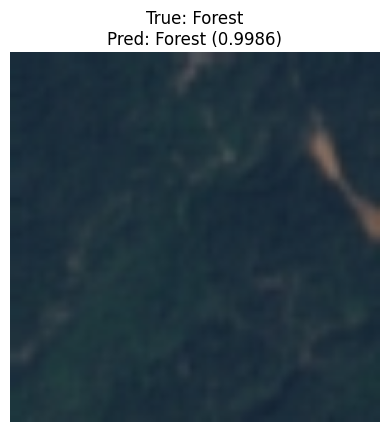

True class: Forest
Predicted class: Forest
Confidence: 0.9986


In [19]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Class names
class_names = dataset.classes

# Get one sample from test set
sample_image, sample_label = test_dataset[0]

# Add batch dimension
input_tensor = sample_image.unsqueeze(0).to(device)

# Predict
model.eval()
with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = F.softmax(outputs, dim=1)
    confidence, predicted_idx = torch.max(probabilities, 1)

predicted_class = class_names[predicted_idx.item()]
true_class = class_names[sample_label]
confidence_score = confidence.item()

# Show image
image_for_display = sample_image.permute(1, 2, 0).cpu().numpy()

# Unnormalize for display
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

image_for_display = image_for_display * std + mean
image_for_display = image_for_display.clip(0, 1)

plt.imshow(image_for_display)
plt.axis("off")
plt.title(f"True: {true_class}\nPred: {predicted_class} ({confidence_score:.4f})")
plt.show()

print("True class:", true_class)
print("Predicted class:", predicted_class)
print("Confidence:", round(confidence_score, 4))

Cell 19: Simple MVP JSON-style output


In [20]:

result = {
    "status": "success",
    "predicted_class": predicted_class,
    "confidence": round(confidence_score, 4)
}

print(result)

{'status': 'success', 'predicted_class': 'Forest', 'confidence': 0.9986}


Cell 20: Full evaluation metrics on the test set

Accuracy: 0.9856
Weighted Precision: 0.9856
Weighted Recall: 0.9856
Weighted F1-score: 0.9855

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.98      0.98       300
              Forest       1.00      1.00      1.00       300
HerbaceousVegetation       0.98      0.97      0.97       300
             Highway       0.97      1.00      0.99       250
          Industrial       0.99      0.99      0.99       250
             Pasture       0.99      0.97      0.98       200
       PermanentCrop       0.96      0.96      0.96       250
         Residential       0.99      1.00      1.00       300
               River       0.99      0.98      0.98       250
             SeaLake       1.00      1.00      1.00       300

            accuracy                           0.99      2700
           macro avg       0.99      0.98      0.99      2700
        weighted avg       0.99      0.99      0.99      2700


Classifica

,precision,recall,f1-score,support
AnnualCrop,0.983278,0.980000,0.981636,300.000000
Forest,1.000000,1.000000,1.000000,300.000000
HerbaceousVegetation,0.979798,0.970000,0.974874,300.000000
Highway,0.972763,1.000000,0.986193,250.000000
Industrial,0.992000,0.992000,0.992000,250.000000
Pasture,0.989848,0.975000,0.982368,200.000000
PermanentCrop,0.956175,0.960000,0.958084,250.000000
Residential,0.993355,0.996667,0.995008,300.000000
River,0.987854,0.976000,0.981891,250.000000
SeaLake,0.996678,1.000000,0.998336,300.000000



Summary Metrics Table:


,Metric,Value
0,Accuracy,0.985556
1,Weighted Precision,0.985593
2,Weighted Recall,0.985556
3,Weighted F1-score,0.985545


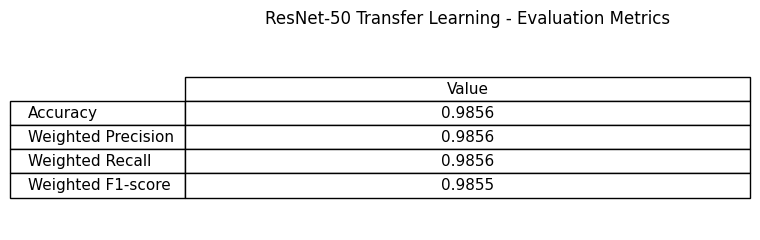

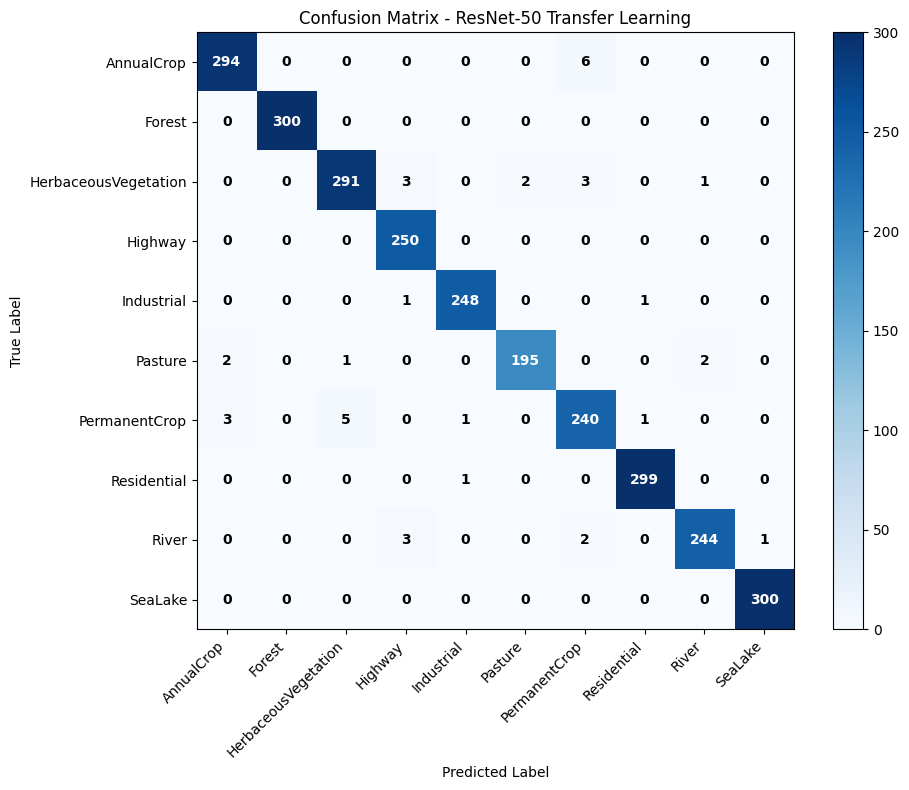

In [21]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

# 1. Load best saved model
model.load_state_dict(torch.load("best_resnet_satellite_model.pth", map_location=device))
model.eval()

# 2. Get predictions on test set
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 3. Compute overall metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-score: {f1:.4f}")

# 4. Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=dataset.classes))

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=dataset.classes,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
print("\nClassification Report Table:")
display(report_df)

report_df.to_csv("resnet50_classification_report.csv", index=True)

# 5. Separate summary metrics table
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Weighted Precision", "Weighted Recall", "Weighted F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

print("\nSummary Metrics Table:")
display(metrics_df)

metrics_df.to_csv("resnet50_summary_metrics.csv", index=False)

# 6. Save summary metrics table as image
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis("off")
table = ax.table(
    cellText=np.round(metrics_df[["Value"]].values, 4),
    rowLabels=metrics_df["Metric"],
    colLabels=["Value"],
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)
plt.title("ResNet-50 Transfer Learning - Evaluation Metrics", pad=15)
plt.tight_layout()
plt.savefig("resnet50_metrics_table.png", dpi=300, bbox_inches="tight")
plt.show()

# 7. Confusion matrix with numbers
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")

ax.set_title("Confusion Matrix - ResNet-50 Transfer Learning")
fig.colorbar(im, ax=ax)

tick_marks = np.arange(len(dataset.classes))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(dataset.classes, rotation=45, ha="right")
ax.set_yticklabels(dataset.classes)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

threshold = cm.max() / 2.0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, f"{cm[i, j]}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.tight_layout()
plt.savefig("resnet50_confusion_matrix_with_numbers.png", dpi=300, bbox_inches="tight")
plt.show()

Cell 21: Plot training and validation curves


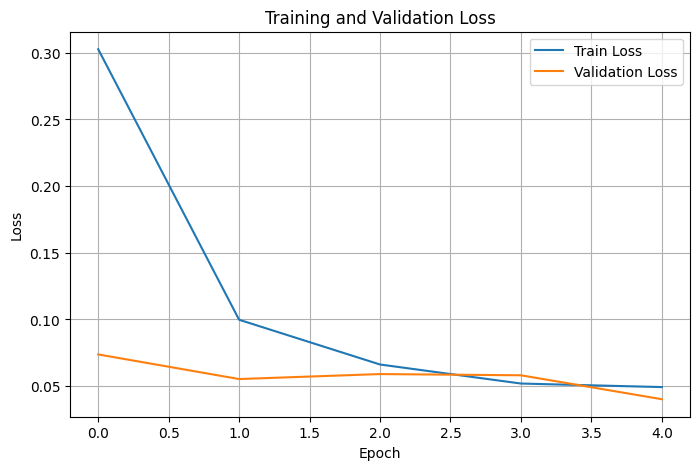

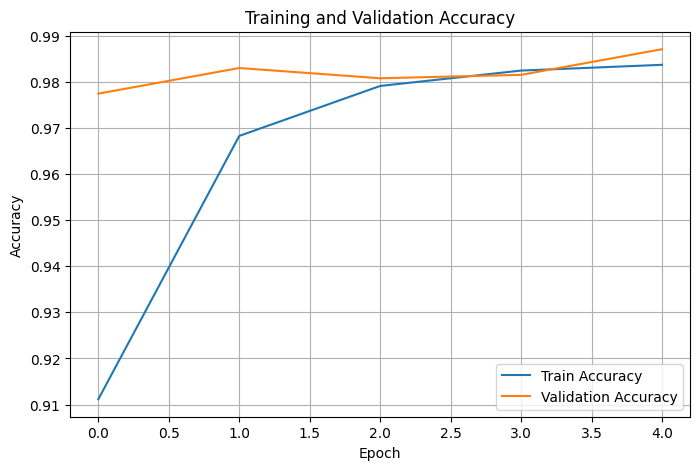

In [22]:
import matplotlib.pyplot as plt

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Cell 22: Save class names and key metrics


In [23]:
import json

artifacts = {
    "classes": dataset.classes,
    "test_accuracy": round(test_acc, 4),
    "single_prediction_class": predicted_class,
    "single_prediction_confidence": round(confidence_score, 4)
}

with open("ml_artifacts.json", "w") as f:
    json.dump(artifacts, f, indent=4)

print("Saved ml_artifacts.json")
print(artifacts)

Saved ml_artifacts.json
{'classes': ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake'], 'test_accuracy': 0.9856, 'single_prediction_class': 'Forest', 'single_prediction_confidence': 0.9986}


In [24]:
import os

print(os.listdir("/kaggle/working"))

['resnet50_summary_metrics.csv', 'best_resnet_satellite_model.pth', 'resnet50_metrics_table.png', 'ml_artifacts.json', '__notebook__.ipynb', 'resnet50_confusion_matrix_with_numbers.png', 'resnet50_classification_report.csv']


In [25]:
import zipfile
import os

files_to_save = [
    "/kaggle/working/best_resnet_satellite_model.pth",
    "/kaggle/working/ml_artifacts.json"
]

zip_path = "/kaggle/working/ml_model_bundle.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for file_path in files_to_save:
        if os.path.exists(file_path):
            zipf.write(file_path, arcname=os.path.basename(file_path))
            print(f"Added: {file_path}")
        else:
            print(f"Missing: {file_path}")

print(f"Created zip: {zip_path}")
print("Files now in /kaggle/working:", os.listdir("/kaggle/working"))

Added: /kaggle/working/best_resnet_satellite_model.pth
Added: /kaggle/working/ml_artifacts.json
Created zip: /kaggle/working/ml_model_bundle.zip
Files now in /kaggle/working: ['ml_model_bundle.zip', 'resnet50_summary_metrics.csv', 'best_resnet_satellite_model.pth', 'resnet50_metrics_table.png', 'ml_artifacts.json', '__notebook__.ipynb', 'resnet50_confusion_matrix_with_numbers.png', 'resnet50_classification_report.csv']


In [26]:
import os

print(os.listdir("/kaggle/working"))
print("model exists:", os.path.exists("/kaggle/working/best_resnet_satellite_model.pth"))
print("json exists:", os.path.exists("/kaggle/working/ml_artifacts.json"))

['ml_model_bundle.zip', 'resnet50_summary_metrics.csv', 'best_resnet_satellite_model.pth', 'resnet50_metrics_table.png', 'ml_artifacts.json', '__notebook__.ipynb', 'resnet50_confusion_matrix_with_numbers.png', 'resnet50_classification_report.csv']
model exists: True
json exists: True
